In [13]:
from netCDF4 import Dataset
import datetime
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
from ll_xy import lonlat_to_xy
import warnings
import matplotlib.pyplot as plt
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [14]:
directory = '/media/robbie/Elements/KUKA/KUKA_PROCESSED/20231003'
# directory = '/home/robbie/Dropbox/kuka_slush/data/kuka/20231003'

pits = {}

/tmp/ipykernel_8414/1551434025.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')


Text(0, 0.5, 'y distance (m)')

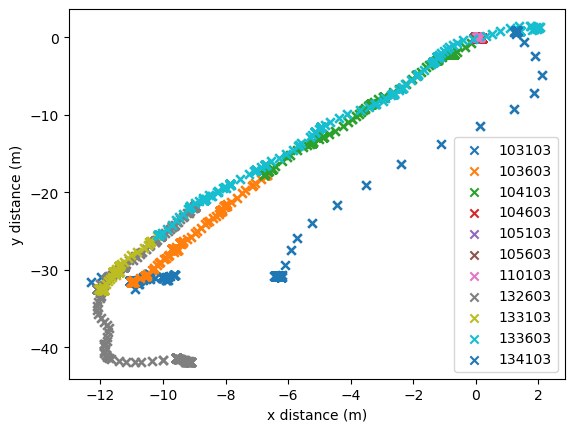

In [15]:
x0,y0 = 0,0

def plot_pos(file,plot=True,x0=0,y0=0):
    
    d = Dataset(f'{directory}/{file}')
    x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')
    y = y[np.abs(x)>10_000] -y0
    x = x[np.abs(x)>10_000] -x0
    if plot:
        plt.scatter(x,y,marker='x',label=file[-9:-3])

    return (x,y)

x,y=plot_pos('kuka_stare_decon_Ka-Scat20231003-105603.nc',plot=False)

x0 = x[0]; y0 = y[0]


plot_pos('kuka_stare_decon_Ka-Scat20231003-103103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-103603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-104103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-104603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-105103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-105603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-110103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-132603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-133103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-133603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-134103.nc',x0=x0,y0=y0)

plt.legend()
plt.xlabel('x distance (m)')
plt.ylabel('y distance (m)')

# plt.xlim(-20,5)
# plt.ylim(-20,5)

/tmp/ipykernel_8414/1692802467.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')


Text(0, 0.5, 'y distance (m)')

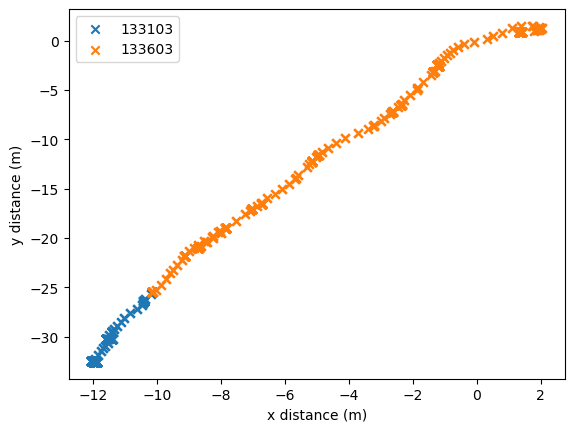

In [16]:
x0,y0 = 0,0

def plot_pos(file,plot=True,x0=0,y0=0):
    
    d = Dataset(f'{directory}/{file}')
    x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')
    y = y[np.abs(x)>10_000] -y0
    x = x[np.abs(x)>10_000] -x0
    if plot:
        plt.scatter(x,y,marker='x',label=file[-9:-3])

    return (x,y)

x,y=plot_pos('kuka_stare_decon_Ka-Scat20231003-105603.nc',plot=False)

x0 = x[0]; y0 = y[0]


# plot_pos('kuka_stare_decon_Ka-Scat20231003-103103.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-103603.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-104103.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-104603.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-105103.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-105603.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-110103.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-132603.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-133103.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231003-133603.nc',x0=x0,y0=y0)
# plot_pos('kuka_stare_decon_Ka-Scat20231003-134103.nc',x0=x0,y0=y0)

plt.legend()
plt.xlabel('x distance (m)')
plt.ylabel('y distance (m)')

# plt.xlim(-20,5)
# plt.ylim(-20,5)

In [17]:
pits = {}

In [18]:
# # Offset between Ka & ku
fa = 'kuka_stare_decon_Ka-Scat20231003-133103.nc'

fu = 'kuka_stare_decon_Ku-Scat20231003-132908.nc'

ka = Dataset(f'{directory}/{fa}')['start_time'][0]
ku = Dataset(f'{directory}/{fu}')['start_time'][0]
ka-ku

np.float64(114.87611842155457)

recording start 55:30

recording end 1:02:30

hand out at 00:59

datetime.timedelta(seconds=1580)

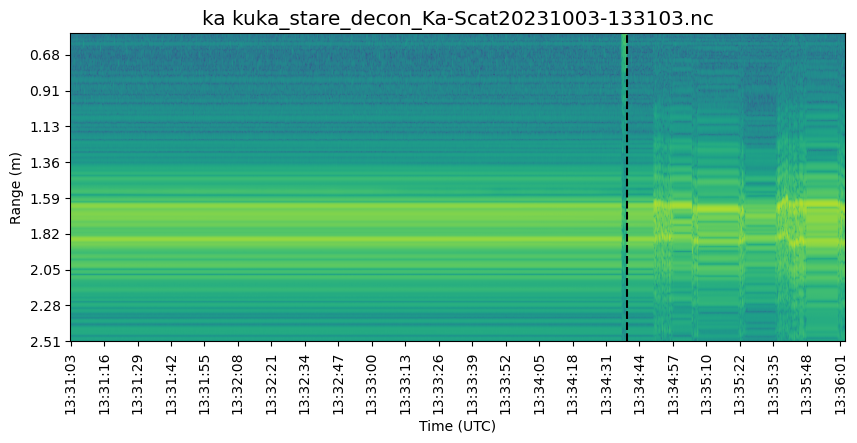

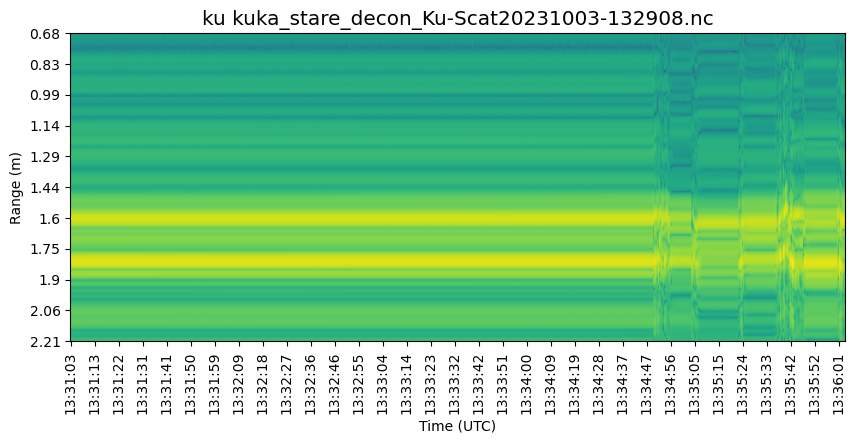

In [19]:
fa = 'kuka_stare_decon_Ka-Scat20231003-133103.nc'

fu = 'kuka_stare_decon_Ku-Scat20231003-132908.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(34,39)]
vlines = [datetime.datetime(2023,10,3,13,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,11,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+115,vlines=vlines,directory=directory)

# Voice recording indicates that 10:37:55 kuka time is equal to 07:46:04 on phone

local_delta = datetime.datetime(2023,10,3,14,0,59)-datetime.datetime(2023,10,3,13,34,39)
local_delta

[np.int64(571)]


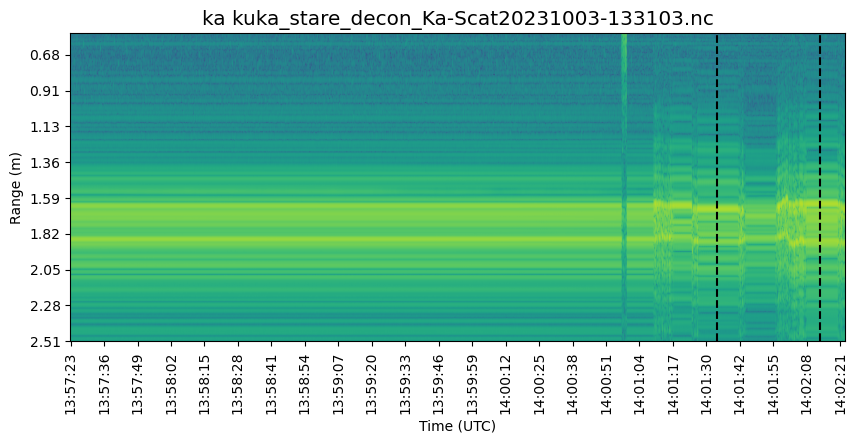

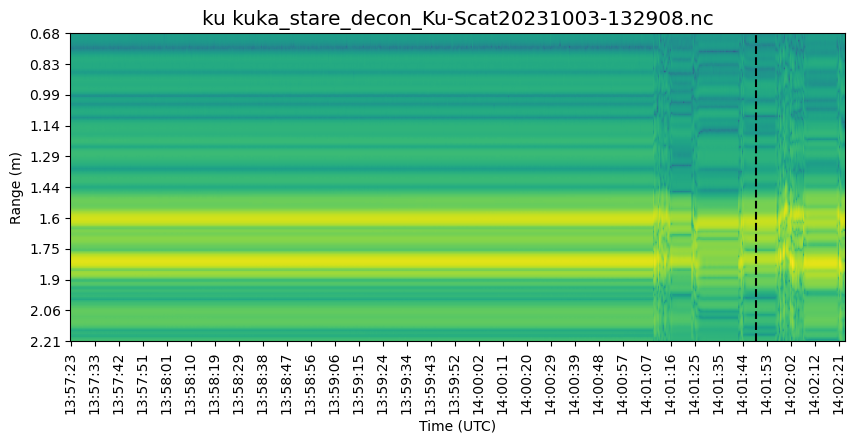

In [20]:
fa = 'kuka_stare_decon_Ka-Scat20231003-133103.nc'

fu = 'kuka_stare_decon_Ku-Scat20231003-132908.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(1,34),(2,14)]
vlines = [datetime.datetime(2023,10,3,14,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

ka_inds = kt.plot_file(fa,'ka',time_offset_s=local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(1,49)]
vlines = [datetime.datetime(2023,10,3,14,a,b)+time_addition for (a,b) in ku_times]

ku_inds = kt.plot_file(fu,'ku',time_offset_s=local_delta.seconds+115,vlines=vlines,directory=directory)
print(ku_inds)
pit_numbers = [1]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

# Here are the pit indices

In [21]:
file: 'kuka_stare_decon_Ku-Scat20231003-132908.nc'
ind = 571
file: 'kuka_stare_decon_Ku-Scat20231003-133409.nc'
inds = 6,131,206,277,353,415

In [22]:
# Special case of loc 2 as the ka & ku straddle the files:

pits[2] = {'ku':6,'ka':1120,
           'ku_file':'kuka_stare_decon_Ku-Scat20231003-133409.nc',
           'ka_file':'kuka_stare_decon_Ka-Scat20231003-133103.nc',
          }

[np.int64(131), np.int64(206), np.int64(277), np.int64(353), np.int64(415)]


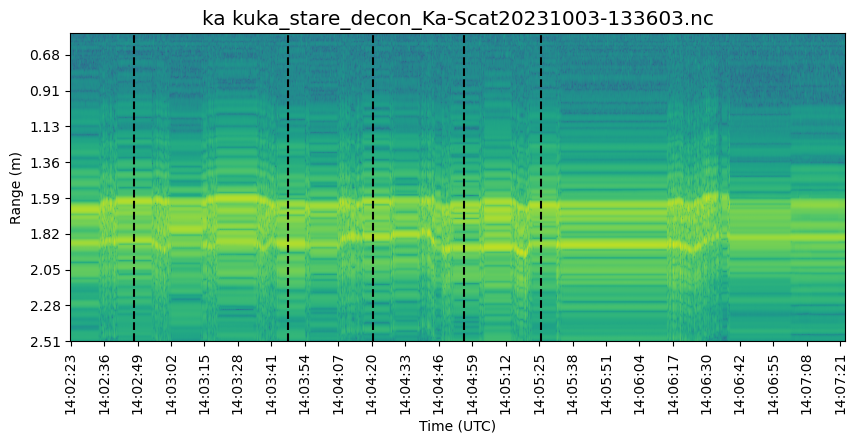

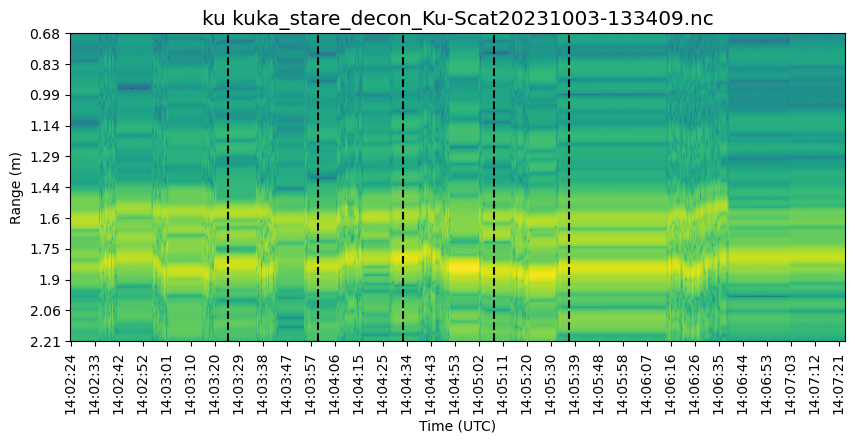

In [23]:
fa = 'kuka_stare_decon_Ka-Scat20231003-133603.nc'

fu = 'kuka_stare_decon_Ku-Scat20231003-133409.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(2,48),(3,48),(4,21),(4,56),(5,26)]
vlines = [datetime.datetime(2023,10,3,14,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

ka_inds = kt.plot_file(fa,'ka',time_offset_s=local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(3,25),(4,0),(4,33),(5,8),(5,37)]
vlines = [datetime.datetime(2023,10,3,14,a,b)+time_addition for (a,b) in ku_times]
ku_inds = kt.plot_file(fu,'ku',time_offset_s=local_delta.seconds+115,vlines=vlines,directory=directory)
print(ku_inds)
pit_numbers = [3,4,5,6,7]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

In [24]:
pols = ['hh','vv','hv','vh']

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

/tmp/ipykernel_8414/3573535974.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranges = np.array(d['range'])
/tmp/ipykernel_8414/3573535974.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)


In [25]:
for freq in ['ka','ku']:

    for h in pits.keys():
    
        data = pits[h]
    
        dic = {pol:data[f'{freq}_{pol}'] for pol in pols}
        
        wvfms = pd.DataFrame(dic)
    
        wvfms.to_csv(f'../data/waveforms/Hangar_2023103_b_{h}_{freq}.csv')

In [27]:
for key in pits:

    x=pits[key]['ka']
    print(x)

966
1120
94
325
452
588
703
